## How many people have I seen?
This is being done in 2 ways. The first is from a "direct" plane of view vs seeing something from a distance. 

The average person spends about 2.4 hours outside per day — commuting, errands, recreation — that's exactly 10% of a 24-hour period. NYC-specific context makes it feel right too: Bed-Stuy's total population from your data is roughly 168,000. At 10%, that's ~16,800 people on streets at any moment, across ~300 blocks — about 56 people per block. That matches what a typical residential Brooklyn block feels like on a weekday afternoon.

The honest caveat is that 10% is a daily average — it compresses a lot of variation:

Peak commute hours (8-9am, 5-7pm): closer to 20-25%
Weekend afternoon: 15-20%
Late night: near 0%

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

BUFFER_CRS   = 2263
WORKING_CRS  = 4326

BUFFERS = {
    "direct":        30,   # ft — buildings lining the streets you walked
    "field_of_view": 250,  # ft — visible from intersections / down the block
}

# Load inputs
pluto = gpd.read_file("outputs/population_by_taxlot_bedstuy.geojson")
path  = gpd.read_file("/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/Walkpath.geojson").to_crs(BUFFER_CRS)

# Reproject pluto to feet for the spatial ops
pluto_ft  = pluto.to_crs(BUFFER_CRS)
total_pop = pluto["est_pop_per_lot"].sum()

# Run both buffers
results = {}
for label, dist in BUFFERS.items():
    buffered    = path.buffer(dist).union_all()
    intersected = pluto_ft[pluto_ft.geometry.intersects(buffered)]
    pop_seen    = intersected["est_pop_per_lot"].sum()
    results[label] = {
        "pop_seen":          pop_seen,
        "pct_seen":          pop_seen / total_pop * 100,
        "lots_intersected":  len(intersected),
        "buffered_geom":     buffered,
    }

# Print results
for label, r in results.items():
    print(f"\n{label.upper()}")
    print(f"  Lots intersected : {r['lots_intersected']}")
    print(f"  Population seen  : {r['pop_seen']:.0f}")
    print(f"  % of Bed-Stuy    : {r['pct_seen']:.1f}%")


DIRECT
  Lots intersected : 150
  Population seen  : 3330
  % of Bed-Stuy    : 2.0%

FIELD_OF_VIEW
  Lots intersected : 1201
  Population seen  : 25788
  % of Bed-Stuy    : 15.3%


## Two ways of viewing

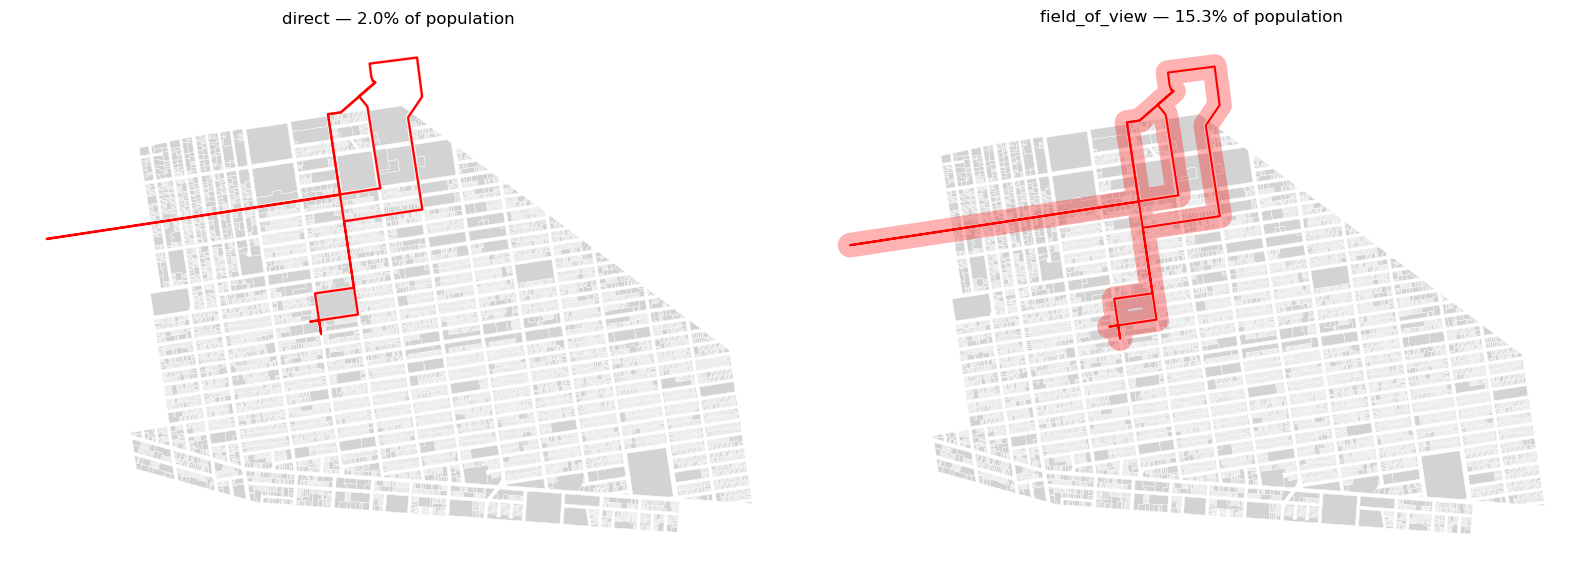

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (label, r) in zip(axes, results.items()):
    pluto.to_crs(WORKING_CRS).plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.3)
    gpd.GeoSeries([r["buffered_geom"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color="red", alpha=0.3
    )
    path.to_crs(WORKING_CRS).plot(ax=ax, color="red", linewidth=1.5)
    ax.set_title(f"{label} — {r['pct_seen']:.1f}% of population")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
fig.savefig("outputs/WalkViews.png", dpi=150, bbox_inches="tight")

In [4]:
OUTDOOR_RATE = 0.10

print(f"Total Bed-Stuy population (estimated): {total_pop:,.0f}")
print(f"People on streets at any moment (10%): {total_pop * OUTDOOR_RATE:,.0f}")
print()

for label, r in results.items():
    encountered = r["pop_seen"] * OUTDOOR_RATE
    print(f"{label.upper()}")
    print(f"  Assumption 1 — seeing a building = seeing a person")
    print(f"    Population in range : {r['pop_seen']:,.0f} ({r['pct_seen']:.1f}%)")
    print(f"  Assumption 2 — 10% of residents are outside")
    print(f"    People encountered  : {encountered:,.0f} ({encountered / total_pop * 100:.2f}%)")
    print()

Total Bed-Stuy population (estimated): 168,572
People on streets at any moment (10%): 16,857

DIRECT
  Assumption 1 — seeing a building = seeing a person
    Population in range : 3,330 (2.0%)
  Assumption 2 — 10% of residents are outside
    People encountered  : 333 (0.20%)

FIELD_OF_VIEW
  Assumption 1 — seeing a building = seeing a person
    Population in range : 25,788 (15.3%)
  Assumption 2 — 10% of residents are outside
    People encountered  : 2,579 (1.53%)



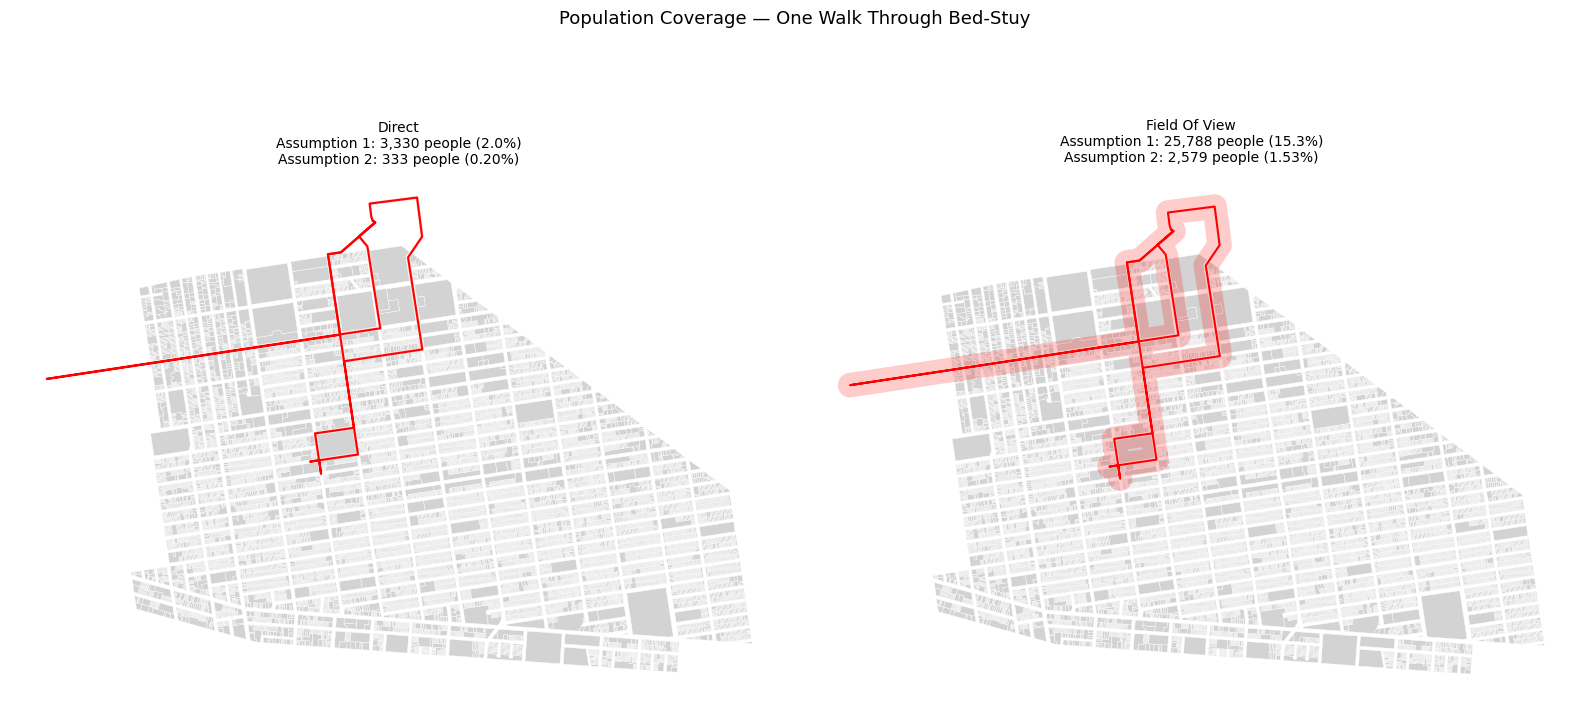

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, (label, r) in zip(axes, results.items()):
    encountered = r["pop_seen"] * OUTDOOR_RATE

    pluto.to_crs(WORKING_CRS).plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.3)
    gpd.GeoSeries([r["buffered_geom"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color="red", alpha=0.2
    )
    path.to_crs(WORKING_CRS).plot(ax=ax, color="red", linewidth=1.5)

    ax.set_title(
        f"{label.replace('_', ' ').title()}\n"
        f"Assumption 1: {r['pop_seen']:,.0f} people ({r['pct_seen']:.1f}%)\n"
        f"Assumption 2: {encountered:,.0f} people ({encountered / total_pop * 100:.2f}%)",
        fontsize=10
    )
    ax.axis("off")

plt.suptitle("Population Coverage — One Walk Through Bed-Stuy", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [6]:
fig.savefig("outputs/Population Coverage — One Walk Through Bed-Stuy.png", dpi=150, bbox_inches="tight")

Ok but there is some sloppiness in these assumptions. That statistic is built off of people being out of their house but not on the street. 

In [7]:
RATES = {
    "ATUS (10% — time use survey proxy)": 0.10,
    "Field Observation (assumed ~2%)":    0.02,
}

BUFFERS = {
    "direct":        50,
    "field_of_view": 250,
}

print(f"Total Bed-Stuy population: {total_pop:,.0f}\n")

for rate_label, rate in RATES.items():
    for buffer_label, dist in BUFFERS.items():
        buffered    = path.to_crs(BUFFER_CRS).buffer(dist).union_all()
        intersected = pluto_ft[pluto_ft.geometry.intersects(buffered)]
        pop_seen    = intersected["est_pop_per_lot"].sum()
        encountered = pop_seen * rate
        print(f"{rate_label} | {buffer_label}")
        print(f"  Lots in range      : {len(intersected):,}")
        print(f"  Population in range: {pop_seen:,.0f} ({pop_seen / total_pop * 100:.1f}%)")
        print(f"  People encountered : {encountered:,.0f} ({encountered / total_pop * 100:.2f}%)")
        print()

Total Bed-Stuy population: 168,572

ATUS (10% — time use survey proxy) | direct
  Lots in range      : 488
  Population in range: 15,633 (9.3%)
  People encountered : 1,563 (0.93%)



ATUS (10% — time use survey proxy) | field_of_view
  Lots in range      : 1,201
  Population in range: 25,788 (15.3%)
  People encountered : 2,579 (1.53%)

Field Observation (assumed ~2%) | direct
  Lots in range      : 488
  Population in range: 15,633 (9.3%)
  People encountered : 313 (0.19%)

Field Observation (assumed ~2%) | field_of_view
  Lots in range      : 1,201
  Population in range: 25,788 (15.3%)
  People encountered : 516 (0.31%)



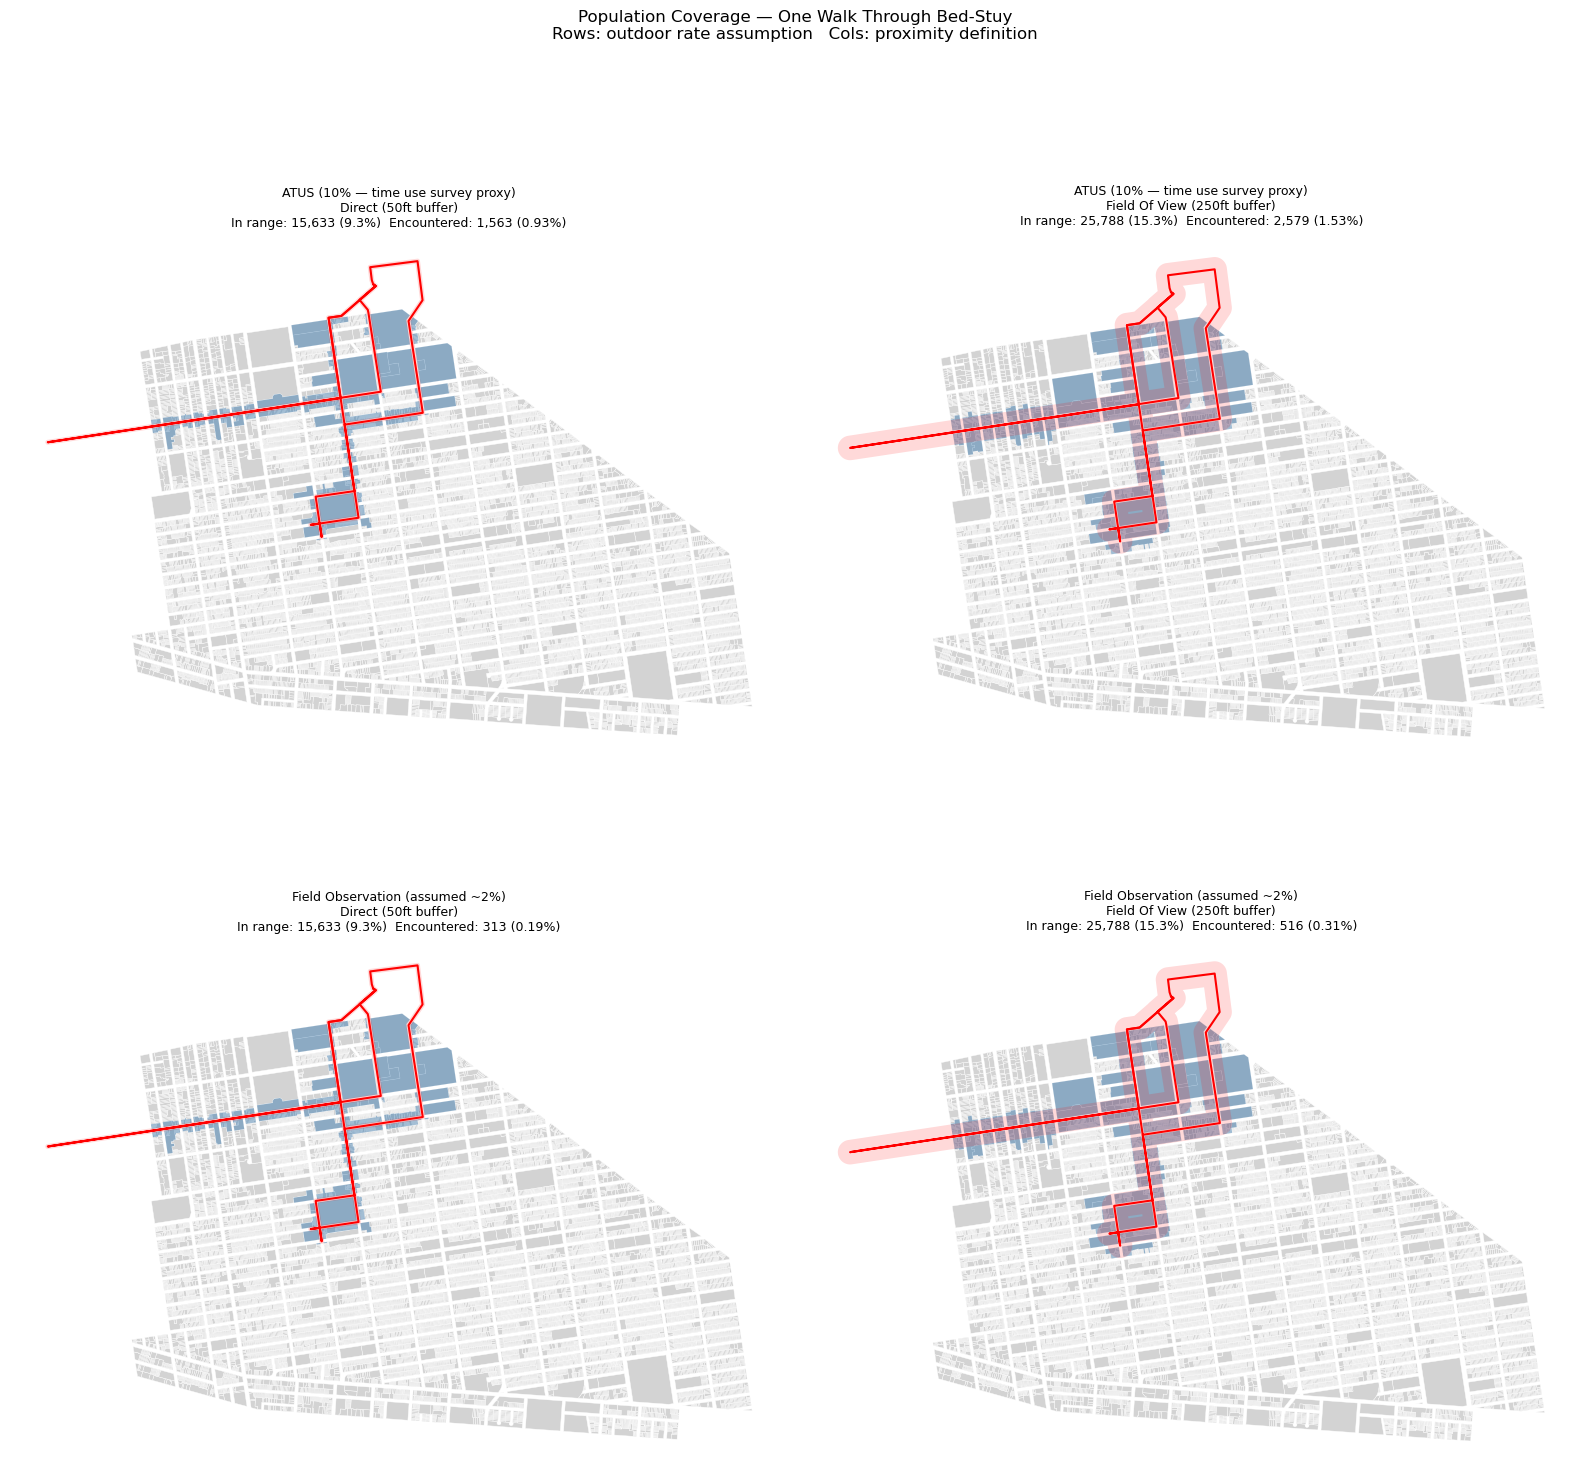

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))

rate_labels   = list(RATES.items())
buffer_labels = list(BUFFERS.items())

for row, (rate_label, rate) in enumerate(rate_labels):
    for col, (buffer_label, dist) in enumerate(buffer_labels):
        ax = axes[row][col]

        buffered    = path.to_crs(BUFFER_CRS).buffer(dist).union_all()
        intersected = pluto_ft[pluto_ft.geometry.intersects(buffered)]
        pop_seen    = intersected["est_pop_per_lot"].sum()
        encountered = pop_seen * rate

        # Base layers
        pluto_ft.to_crs(WORKING_CRS).plot(
            ax=ax, color="lightgray", edgecolor="white", linewidth=0.3
        )
        intersected.to_crs(WORKING_CRS).plot(
            ax=ax, color="steelblue", alpha=0.5, edgecolor="none"
        )
        gpd.GeoSeries([buffered], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
            ax=ax, color="red", alpha=0.15
        )
        path.to_crs(WORKING_CRS).plot(ax=ax, color="red", linewidth=1.5)

        ax.set_title(
            f"{rate_label}\n"
            f"{buffer_label.replace('_', ' ').title()} ({dist}ft buffer)\n"
            f"In range: {pop_seen:,.0f} ({pop_seen / total_pop * 100:.1f}%)  "
            f"Encountered: {encountered:,.0f} ({encountered / total_pop * 100:.2f}%)",
            fontsize=9
        )
        ax.axis("off")

plt.suptitle(
    "Population Coverage — One Walk Through Bed-Stuy\n"
    "Rows: outdoor rate assumption   Cols: proximity definition",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

In [9]:
fig.savefig("outputs/coverage_2x2.png", dpi=150, bbox_inches="tight")

## Designing Three Zone Walks From Home

So far this has tested one fixed, hand-drawn walk. But what if I designed the walk on purpose? Here I split Bed-Stuy into three geographic thirds (West / Central / East) and build an optimized 45-minute (11,880 ft) loop walk for each one — starting and ending at home (678 Broadway, same spot `Walkpath.geojson` starts/ends at), greedily picking whichever connected street reveals the most previously-unseen population per foot in that third, while always keeping enough distance in reserve to actually make it back. Combining all three should cover more ground than one arbitrary path — and sets up the real question: how many times would I need to repeat this 3-walk circuit before expecting to cross paths with 80% of the neighborhood?

One wrinkle worth calling out: 678 Broadway is actually about 500 ft north of Bed-Stuy's tight boundary (technically South/East Williamsburg) — which matches where the hand-drawn walk path starts and ends. Because home isn't centered in the neighborhood, the West and East walks spend a lot of their 45 minutes just getting there and back, leaving less room to actually explore than the closer Central walk.

In [10]:
import math
import networkx as nx
import numpy as np
from shapely.geometry import Point
from shapely.ops import unary_union

FOV_BUFFER_FT = 250    # ft -- field-of-view buffer
FT_PER_MIN    = 264    # 3 mph, used to convert walk distance to time
TARGET_PCT    = 0.80   # direct/geometric coverage target -- no outdoor-rate discount
HOUSE_LONLAT  = (-73.9442242, 40.7018343)  # 678 Broadway, Brooklyn

# Bed-Stuy boundary, same pattern as the cleaning notebook
nta = gpd.read_file(
    "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/2020_Neighborhood_Tabulation_Areas_(NTAs)_20260717.geojson"
).to_crs(WORKING_CRS)
bedstuy_poly    = unary_union(nta[nta["ntaname"].str.contains("Bedford-Stuyvesant", na=False)].geometry)
bedstuy_poly_ft = gpd.GeoSeries([bedstuy_poly], crs=WORKING_CRS).to_crs(BUFFER_CRS).iloc[0]
house_pt_ft     = gpd.GeoSeries([Point(HOUSE_LONLAT)], crs=WORKING_CRS).to_crs(BUFFER_CRS).iloc[0]
print(f"House is {house_pt_ft.distance(bedstuy_poly_ft):.0f} ft from the tight Bed-Stuy boundary")

# Split into equal-longitude thirds of the bounding box
minlon, maxlon = bedstuy_poly.bounds[0], bedstuy_poly.bounds[2]
band = (maxlon - minlon) / 3
lon_bounds = {
    "West":    (minlon,            minlon + band),
    "Central": (minlon + band,     minlon + 2 * band),
    "East":    (minlon + 2 * band, maxlon),
}
ZONE_ORDER  = ["West", "Central", "East"]
ZONE_COLORS = {"West": "tab:blue", "Central": "tab:orange", "East": "tab:green"}

def zone_for_lon(lon):
    for zone, (lo, hi) in lon_bounds.items():
        if lo <= lon <= hi:
            return zone
    return "East" if lon > maxlon else "West"

# Assign each tax lot to a zone by its centroid longitude
pluto["zone"]    = gpd.GeoSeries(pluto_ft.geometry.centroid, crs=BUFFER_CRS).to_crs(WORKING_CRS).x.apply(zone_for_lon)
pluto_ft["zone"] = pluto["zone"].values

print(pluto.groupby("zone")["est_pop_per_lot"].sum().reindex(ZONE_ORDER))

House is 500 ft from the tight Bed-Stuy boundary
zone
West       67412.453552
Central    59664.045107
East       41495.600419
Name: est_pop_per_lot, dtype: float64


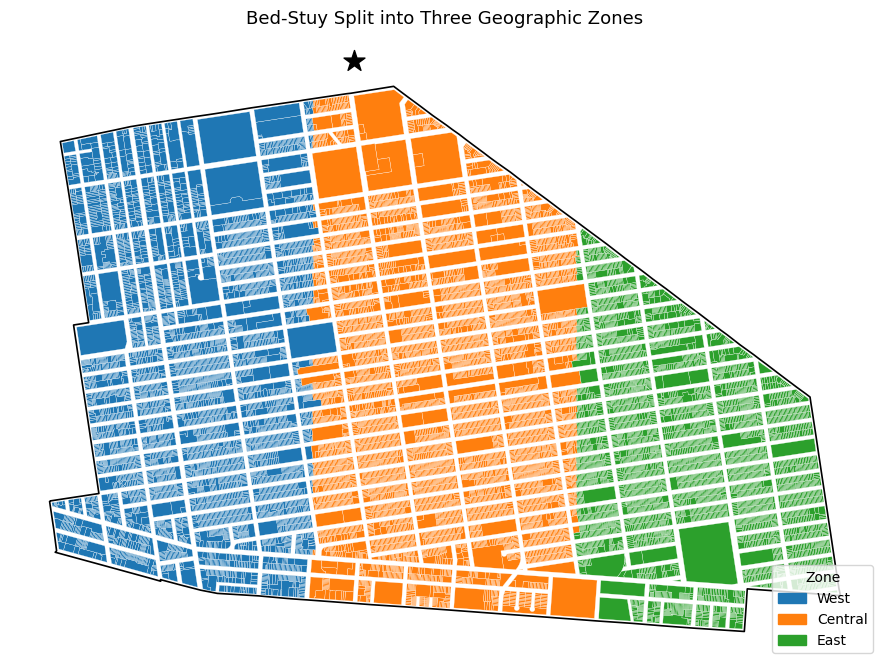

In [11]:
from matplotlib.patches import Patch

pluto_plot    = pluto.to_crs(WORKING_CRS)
house_pt_plot = gpd.GeoSeries([Point(HOUSE_LONLAT)], crs=WORKING_CRS)

fig, ax = plt.subplots(figsize=(9, 9))
for zone in ZONE_ORDER:
    pluto_plot[pluto_plot["zone"] == zone].plot(
        ax=ax, color=ZONE_COLORS[zone], edgecolor="white", linewidth=0.2
    )
gpd.GeoSeries([bedstuy_poly], crs=WORKING_CRS).boundary.plot(ax=ax, color="black", linewidth=1.2)
house_pt_plot.plot(ax=ax, color="black", marker="*", markersize=250, zorder=6)
ax.set_title("Bed-Stuy Split into Three Geographic Zones", fontsize=13)
ax.axis("off")
ax.legend(handles=[Patch(color=ZONE_COLORS[z], label=z) for z in ZONE_ORDER], title="Zone", loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
fig.savefig("outputs/zone_split.png", dpi=150, bbox_inches="tight")

### Building a walkable network that reaches home

The centerline export already carries a 15-minute-walk buffer around the tight Bed-Stuy boundary, which conveniently reaches up to the house. I build one unified street graph over that wider area (so routes to/from home are possible), plus a tight-boundary-clipped subgraph per zone (used only for the in-zone exploration, so each walk's "new ground" stays inside its own third of the neighborhood).

In [13]:
STUDY_BUFFER_FT = 1500  # generous enough to reach the house + connector streets
study_area_ft = bedstuy_poly_ft.buffer(STUDY_BUFFER_FT)

centerline_raw  = gpd.read_file("outputs/centerline_bedstuy.geojson").to_crs(BUFFER_CRS)
centerline_full = centerline_raw[centerline_raw.geometry.intersects(study_area_ft)].copy()
centerline_full = centerline_full.explode(index_parts=False).reset_index(drop=True)
centerline_full = centerline_full[centerline_full.geometry.length > 0].copy()

centerline_tight = centerline_full[centerline_full.geometry.intersects(bedstuy_poly_ft)].copy()
mid_lon = gpd.GeoSeries(
    centerline_tight.geometry.interpolate(0.5, normalized=True), crs=BUFFER_CRS
).to_crs(WORKING_CRS).x
centerline_tight["zone"] = mid_lon.apply(zone_for_lon)

ROUND_FT = 0.5  # merges coincident intersection endpoints after reprojection

def build_graph(edges_gdf):
    G = nx.Graph()
    for edge_id, row in edges_gdf.iterrows():
        coords = list(row.geometry.coords)
        u = (round(coords[0][0] / ROUND_FT) * ROUND_FT, round(coords[0][1] / ROUND_FT) * ROUND_FT)
        v = (round(coords[-1][0] / ROUND_FT) * ROUND_FT, round(coords[-1][1] / ROUND_FT) * ROUND_FT)
        if u != v:
            G.add_edge(u, v, edge_id=edge_id, length=row.geometry.length, geometry=row.geometry)
    return G

# Unified graph: house + connector streets + all three zones
full_graph_raw = build_graph(centerline_full)
full_graph = full_graph_raw.subgraph(max(nx.connected_components(full_graph_raw), key=len)).copy()

house_nodes = np.array(list(full_graph.nodes))
house_dists = np.hypot(house_nodes[:, 0] - house_pt_ft.x, house_nodes[:, 1] - house_pt_ft.y)
house_node  = tuple(house_nodes[np.argmin(house_dists)])
print(f"house_node snapped {house_dists.min():.0f} ft from the actual address")

# Per-zone subgraphs, used only for in-zone exploration
zone_graphs = {}
for zone in ZONE_ORDER:
    G = build_graph(centerline_tight[centerline_tight["zone"] == zone])
    zone_graphs[zone] = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    total_ft = sum(nx.get_edge_attributes(zone_graphs[zone], "length").values())
    print(f"{zone}: {zone_graphs[zone].number_of_edges()} walkable segments, {total_ft:,.0f} ft of street")

house_node snapped 78 ft from the actual address
West: 355 walkable segments, 149,598 ft of street
Central: 446 walkable segments, 165,750 ft of street
East: 261 walkable segments, 99,156 ft of street


### Sizing each walk to actually reach 80%

Earlier this capped each walk at 45 minutes and asked how many *repeat passes* it'd take to probabilistically cross paths with 80% of Bed-Stuy. That's the wrong question for what I actually wanted: how long would these 3 walks (still one per zone, still starting and ending at home) need to be, in a **single pass**, so that 80% of the neighborhood's population directly falls within 250 ft of the route -- no probability, just "did the walk physically pass their building."

Dropping the 45-minute cap outright risks a lopsided answer, since West and Central alone already hold about 75% of Bed-Stuy's population between them -- a naive "exhaust West, then Central, then dip into East" approach would produce two very long walks and one short one. So instead the three walks grow **in lockstep**: at every step, whichever walk is currently the shortest gets extended next (using its own best next street, judged by newly-seen population per foot), until the combined total crosses 80%. That keeps the three walks close in length to each other by construction, rather than letting one zone's walk balloon while another stays short.

In [14]:
lot_pop_dict = pluto_ft["est_pop_per_lot"].fillna(0).to_dict()
sindex = pluto_ft.sindex

# entry node per zone = nearest node (within that zone's own subgraph) to its
# population-weighted centroid -- no round-trip feasibility filter needed now,
# since the walk is allowed to be as long as it needs to be
entry_node    = {}
edge_lot_sets = {}
for zone in ZONE_ORDER:
    zone_lots = pluto_ft[pluto_ft["zone"] == zone]
    w, c = zone_lots["est_pop_per_lot"].fillna(0), zone_lots.geometry.centroid
    wx, wy = np.average(c.x, weights=w), np.average(c.y, weights=w)

    G = zone_graphs[zone]
    nodes = np.array(list(G.nodes))
    dists = np.hypot(nodes[:, 0] - wx, nodes[:, 1] - wy)
    entry_node[zone] = tuple(nodes[np.argmin(dists)])

    for u, v, data in G.edges(data=True):
        buf = data["geometry"].buffer(FOV_BUFFER_FT)
        candidates = pluto_ft.iloc[list(sindex.intersection(buf.bounds))]
        edge_lot_sets[(zone, data["edge_id"])] = set(candidates[candidates.geometry.intersects(buf)].index)

covered = set()
state = {z: dict(current=entry_node[z], distance=0.0, route_geoms=[]) for z in ZONE_ORDER}


def edge_gain(zone, edge_id):
    return sum(lot_pop_dict[i] for i in (edge_lot_sets[(zone, edge_id)] - covered))


def best_immediate_candidate(zone):
    """Best positive-gain edge among the CURRENT node's immediate neighbors, if any."""
    st, G, best = state[zone], zone_graphs[zone], None
    for nbr in G.neighbors(st["current"]):
        data = G[st["current"]][nbr]
        gain = edge_gain(zone, data["edge_id"])
        if gain <= 0:
            continue
        score = gain / data["length"] if data["length"] > 0 else 0.0
        if best is None or score > best[0]:
            best = (score, nbr, data["edge_id"], data["length"], data["geometry"])
    return best


def relocate_path(zone):
    """No positive-gain edge nearby -- find the nearest node (by walked distance) that
    still has ANY incident positive-gain edge, and return the path there. None means
    this zone's connected component has no remaining gain anywhere (fully exhausted)."""
    G = zone_graphs[zone]
    dist_map, path_map = nx.single_source_dijkstra(G, state[zone]["current"], weight="length")
    for node in sorted(dist_map, key=dist_map.get):
        for nbr in G.neighbors(node):
            if edge_gain(zone, G[node][nbr]["edge_id"]) > 0:
                return path_map[node]
    return None


def take_edge(zone, nbr, edge_id, length, geom):
    st = state[zone]
    st["route_geoms"].append(geom)
    st["distance"] += length
    st["current"] = nbr
    covered.update(edge_lot_sets[(zone, edge_id)])


def covered_pop():
    return pluto_ft.loc[pluto_ft.index.isin(covered), "est_pop_per_lot"].sum()


exhausted = set()
while covered_pop() / total_pop < TARGET_PCT:
    active = [z for z in ZONE_ORDER if z not in exhausted]
    if not active:
        print("All zones fully exhausted of new population -- stopping short of target.")
        break
    zone = min(active, key=lambda z: state[z]["distance"])
    G = zone_graphs[zone]

    cand = best_immediate_candidate(zone)
    if cand is None:
        path = relocate_path(zone)
        if path is None:
            exhausted.add(zone)
            continue
        for u, v in zip(path[:-1], path[1:]):
            data = G[u][v]
            take_edge(zone, v, data["edge_id"], data["length"], data["geometry"])
        cand = best_immediate_candidate(zone)

    _, nbr, edge_id, length, geom = cand
    take_edge(zone, nbr, edge_id, length, geom)

print(f"Lockstep growth done. Interior distances: "
      f"{ {z: round(state[z]['distance']) for z in ZONE_ORDER} }")

# close out each walk with the out-leg (home -> entry point) and back-leg (wherever it ended -> home)
walk_results = {}
for zone in ZONE_ORDER:
    st = state[zone]
    out_nodes  = nx.shortest_path(full_graph, house_node, entry_node[zone], weight="length")
    out_geoms  = [full_graph[u][v]["geometry"] for u, v in zip(out_nodes[:-1], out_nodes[1:])]
    out_ft     = sum(full_graph[u][v]["length"] for u, v in zip(out_nodes[:-1], out_nodes[1:]))

    back_nodes = nx.shortest_path(full_graph, st["current"], house_node, weight="length")
    back_geoms = [full_graph[u][v]["geometry"] for u, v in zip(back_nodes[:-1], back_nodes[1:])]
    back_ft    = sum(full_graph[u][v]["length"] for u, v in zip(back_nodes[:-1], back_nodes[1:]))

    interior_ft  = st["distance"]
    total_ft     = out_ft + interior_ft + back_ft
    route_line   = unary_union(out_geoms + st["route_geoms"] + back_geoms)
    route_buffer = route_line.buffer(FOV_BUFFER_FT)
    pop_covered  = pluto_ft.loc[pluto_ft.geometry.intersects(route_buffer), "est_pop_per_lot"].sum()

    walk_results[zone] = dict(out_ft=out_ft, interior_ft=interior_ft, back_ft=back_ft, total_ft=total_ft,
                               route_line=route_line, route_buffer=route_buffer, pop_covered=pop_covered)
    print(f"{zone}: {total_ft:,.0f} ft ({total_ft/5280:.1f} mi, {total_ft/FT_PER_MIN/60:.1f} hr) -- "
          f"out {out_ft:,.0f} / in-zone {interior_ft:,.0f} / back {back_ft:,.0f} -- "
          f"pop covered={pop_covered:,.0f} ({pop_covered / total_pop * 100:.1f}%)")

combined_buffer = unary_union([walk_results[z]["route_buffer"] for z in ZONE_ORDER])
combined_pop    = pluto_ft.loc[pluto_ft.geometry.intersects(combined_buffer), "est_pop_per_lot"].sum()
total_all_ft    = sum(walk_results[z]["total_ft"] for z in ZONE_ORDER)
print(f"\nCombined: {combined_pop:,.0f} people ({combined_pop / total_pop * 100:.1f}% of Bed-Stuy)")
print(f"Total distance across all 3 walks: {total_all_ft:,.0f} ft ({total_all_ft/5280:.1f} mi), "
      f"{total_all_ft/FT_PER_MIN/60:.1f} hours")

Lockstep growth done. Interior distances: {'West': 54027, 'Central': 53822, 'East': 54218}


West: 65,619 ft (12.4 mi, 4.1 hr) -- out 6,857 / in-zone 54,027 / back 4,735 -- pop covered=59,772 (35.5%)


Central: 67,525 ft (12.8 mi, 4.3 hr) -- out 5,442 / in-zone 53,822 / back 8,262 -- pop covered=51,209 (30.4%)


East: 73,848 ft (14.0 mi, 4.7 hr) -- out 8,617 / in-zone 54,218 / back 11,013 -- pop covered=41,739 (24.8%)



Combined: 146,660 people (87.0% of Bed-Stuy)
Total distance across all 3 walks: 206,992 ft (39.2 mi), 13.1 hours


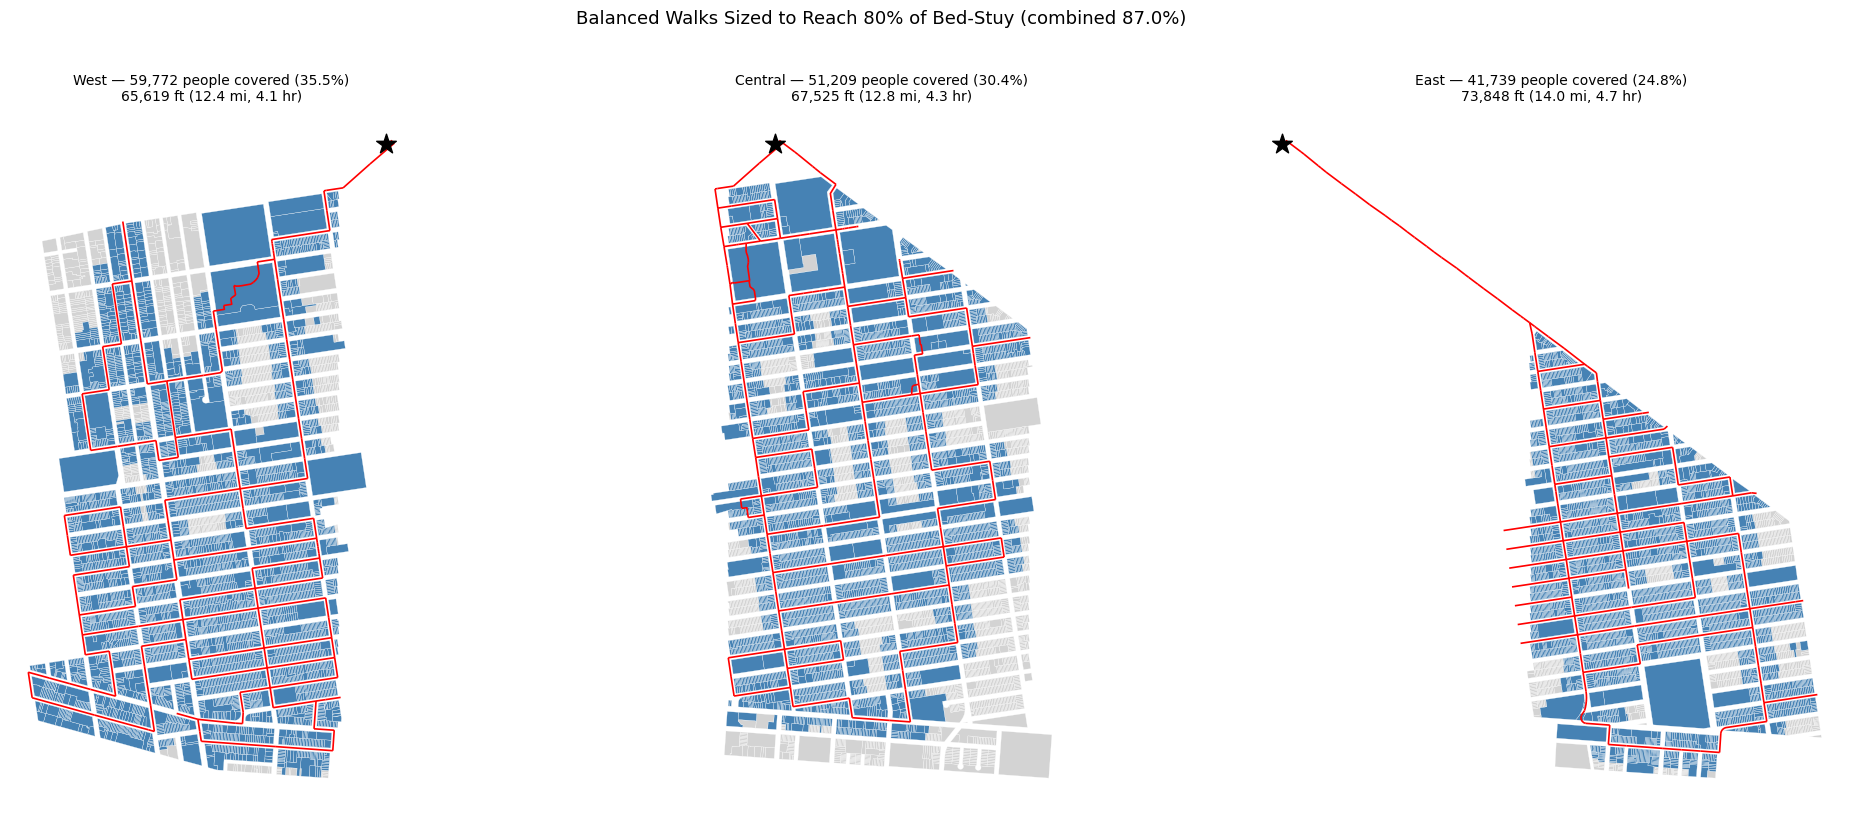

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

for ax, zone in zip(axes, ZONE_ORDER):
    r = walk_results[zone]

    zone_mask    = pluto_ft["zone"] == zone
    covered_mask = zone_mask & pluto_ft.geometry.intersects(r["route_buffer"])

    pluto_plot[zone_mask & ~covered_mask].plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)
    pluto_plot[covered_mask].plot(ax=ax, color="steelblue", edgecolor="white", linewidth=0.2)
    gpd.GeoSeries([r["route_line"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color="red", linewidth=1.2
    )
    house_pt_plot.plot(ax=ax, color="black", marker="*", markersize=220, zorder=6)

    ax.set_title(
        f"{zone} — {r['pop_covered']:,.0f} people covered ({r['pop_covered'] / total_pop * 100:.1f}%)\n"
        f"{r['total_ft']:,.0f} ft ({r['total_ft']/5280:.1f} mi, {r['total_ft']/FT_PER_MIN/60:.1f} hr)",
        fontsize=10
    )
    ax.axis("off")

plt.suptitle(
    f"Balanced Walks Sized to Reach 80% of Bed-Stuy (combined {combined_pop/total_pop*100:.1f}%)",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

In [16]:
fig.savefig("outputs/walk_paths.png", dpi=150, bbox_inches="tight")

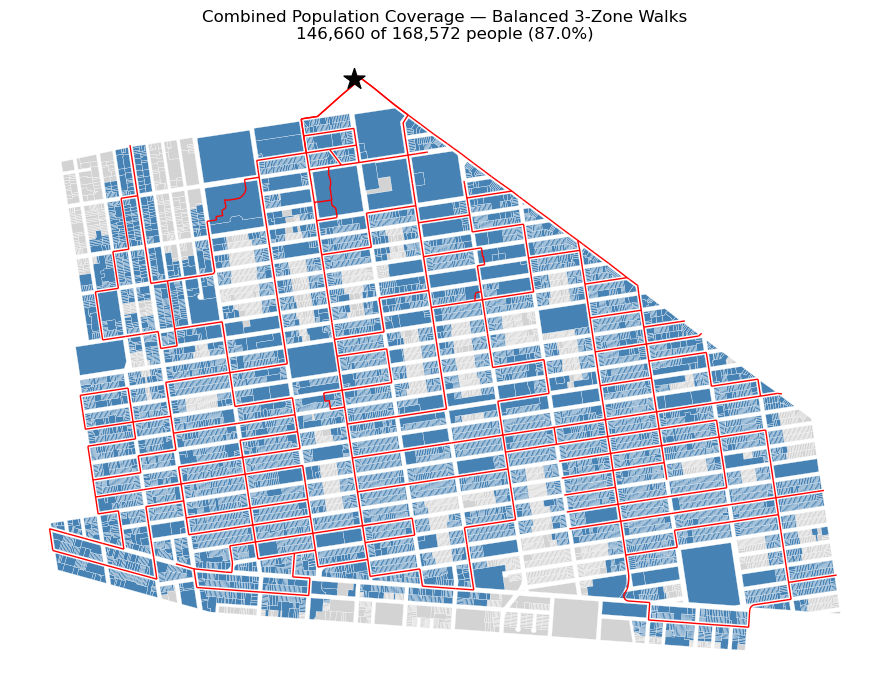

In [17]:
combined_covered = pluto_ft.geometry.intersects(combined_buffer)

fig, ax = plt.subplots(figsize=(9, 9))
pluto_plot[~combined_covered].plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)
pluto_plot[combined_covered].plot(ax=ax, color="steelblue", edgecolor="white", linewidth=0.2)
for zone in ZONE_ORDER:
    gpd.GeoSeries([walk_results[zone]["route_line"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
        ax=ax, color="red", linewidth=1
    )
house_pt_plot.plot(ax=ax, color="black", marker="*", markersize=250, zorder=6)

ax.set_title(
    f"Combined Population Coverage — Balanced 3-Zone Walks\n"
    f"{combined_pop:,.0f} of {total_pop:,.0f} people ({combined_pop / total_pop * 100:.1f}%)",
    fontsize=12
)
ax.axis("off")
plt.tight_layout()
plt.show()

In [18]:
fig.savefig("outputs/coverage_map.png", dpi=150, bbox_inches="tight")

### The answer

With the 45-minute cap dropped and the three walks grown in lockstep so they stay comparable in length, here's how far each one actually needs to be to directly put 80% of Bed-Stuy within 250 ft of the route:

In [19]:
print(f"To directly see {TARGET_PCT*100:.0f}% of Bed-Stuy's population (no outdoor-rate discount, just")
print("'building = person'), starting and ending each walk at home:\n")
for zone in ZONE_ORDER:
    r = walk_results[zone]
    print(f"  {zone:<8}: {r['total_ft']:>7,.0f} ft  ({r['total_ft']/5280:4.1f} mi, {r['total_ft']/FT_PER_MIN/60:4.1f} hr)")

total_all_ft = sum(walk_results[z]["total_ft"] for z in ZONE_ORDER)
print(f"\n  {'Combined':<8}: {total_all_ft:>7,.0f} ft  ({total_all_ft/5280:4.1f} mi, {total_all_ft/FT_PER_MIN/60:4.1f} hr total walking)")
print(f"  Actual coverage achieved: {combined_pop:,.0f} / {total_pop:,.0f} people ({combined_pop/total_pop*100:.1f}%)")

To directly see 80% of Bed-Stuy's population (no outdoor-rate discount, just
'building = person'), starting and ending each walk at home:

  West    :  65,619 ft  (12.4 mi,  4.1 hr)
  Central :  67,525 ft  (12.8 mi,  4.3 hr)
  East    :  73,848 ft  (14.0 mi,  4.7 hr)

  Combined: 206,992 ft  (39.2 mi, 13.1 hr total walking)
  Actual coverage achieved: 146,660 / 168,572 people (87.0%)


## Repeating Trips Until Each Zone Plateaus

The first attempt at this split each zone's walk into a fixed 4 trips of 45 minutes. But 45 minutes turned out to be too short to be a useful unit here: every trip has to pay the commute to and from home out of its own budget, so a 45-minute round trip barely leaves any time to actually explore before it has to turn back. Bumping each trip to **2 hours** and repeating trips per zone until an additional trip stops finding any new people (not a fixed count) answers the real question: how many of these repeated round trips would it actually take, and where do they plateau?

In [20]:
TRIP_HOURS  = 2
MAX_TRIP_FT = TRIP_HOURS * 60 * FT_PER_MIN  # 2-hour round-trip budget per trip

dist_home = nx.single_source_dijkstra_path_length(full_graph, house_node, weight="length")


def pick_trip_entry_node(zone, covered_zone):
    """Feasible (round-trip within MAX_TRIP_FT) node in this zone closest to the
    population-weighted centroid of that zone's still-uncovered lots."""
    G = zone_graphs[zone]
    feasible_nodes = [n for n in G.nodes if n in dist_home and 2 * dist_home[n] <= MAX_TRIP_FT]
    if not feasible_nodes:
        feasible_nodes = sorted((n for n in G.nodes if n in dist_home), key=lambda n: dist_home[n])[:1]

    zone_lots = pluto_ft[(pluto_ft["zone"] == zone) & (~pluto_ft.index.isin(covered_zone))]
    if len(zone_lots) == 0 or zone_lots["est_pop_per_lot"].sum() <= 0:
        zone_lots = pluto_ft[pluto_ft["zone"] == zone]  # nothing left uncovered -- fall back to the zone overall
    w, c = zone_lots["est_pop_per_lot"].fillna(0), zone_lots.geometry.centroid
    wx, wy = np.average(c.x, weights=w), np.average(c.y, weights=w)

    nodes = np.array(feasible_nodes)
    dists = np.hypot(nodes[:, 0] - wx, nodes[:, 1] - wy)
    return tuple(nodes[np.argmin(dists)])


def greedy_trip_walk(zone, start_node, remaining_after_out, covered_zone):
    """Budgeted greedy walk that relocates (within budget) to the nearest remaining
    opportunity instead of stopping the moment the immediate neighborhood is used up."""
    G = zone_graphs[zone]
    current, cumulative, route_geoms = start_node, 0.0, []

    while True:
        candidates = []
        for nbr in G.neighbors(current):
            data = G[current][nbr]
            length = data["length"]
            if nbr not in dist_home or cumulative + length + dist_home[nbr] > remaining_after_out:
                continue
            lots = edge_lot_sets[(zone, data["edge_id"])]
            gain = sum(lot_pop_dict[i] for i in (lots - covered_zone))
            score = gain / length if length > 0 else 0.0
            candidates.append((score, nbr, data["edge_id"], length, lots, data["geometry"], gain))
        positive = [c for c in candidates if c[6] > 0]
        if positive:
            positive.sort(key=lambda c: c[0], reverse=True)
            _, nbr, edge_id, length, lots, geom, _ = positive[0]
            route_geoms.append(geom)
            cumulative += length
            covered_zone.update(lots)
            current = nbr
            continue

        dist_map, path_map = nx.single_source_dijkstra(G, current, weight="length")
        target = None
        for node in sorted(dist_map, key=dist_map.get):
            if cumulative + dist_map[node] > remaining_after_out:
                break
            if node == current:
                continue
            for nbr2 in G.neighbors(node):
                d2 = G[node][nbr2]
                if nbr2 not in dist_home:
                    continue
                if cumulative + dist_map[node] + d2["length"] + dist_home[nbr2] > remaining_after_out:
                    continue
                gain2 = sum(lot_pop_dict[i] for i in (edge_lot_sets[(zone, d2["edge_id"])] - covered_zone))
                if gain2 > 0:
                    target = node
                    break
            if target is not None:
                break
        if target is None:
            break
        for u, v in zip(path_map[target][:-1], path_map[target][1:]):
            data = G[u][v]
            route_geoms.append(data["geometry"])
            cumulative += data["length"]
            covered_zone.update(edge_lot_sets[(zone, data["edge_id"])])
        current = target

    return current, cumulative, route_geoms


def run_one_trip(zone, covered_zone):
    entry = pick_trip_entry_node(zone, covered_zone)
    out_nodes = nx.shortest_path(full_graph, house_node, entry, weight="length")
    out_ft = sum(full_graph[u][v]["length"] for u, v in zip(out_nodes[:-1], out_nodes[1:]))
    out_geoms = [full_graph[u][v]["geometry"] for u, v in zip(out_nodes[:-1], out_nodes[1:])]

    end_node, interior_ft, interior_geoms = greedy_trip_walk(zone, entry, MAX_TRIP_FT - out_ft, covered_zone)

    back_nodes = nx.shortest_path(full_graph, end_node, house_node, weight="length")
    back_ft = sum(full_graph[u][v]["length"] for u, v in zip(back_nodes[:-1], back_nodes[1:]))
    back_geoms = [full_graph[u][v]["geometry"] for u, v in zip(back_nodes[:-1], back_nodes[1:])]

    total_ft = out_ft + interior_ft + back_ft
    route_line = unary_union(out_geoms + interior_geoms + back_geoms)
    route_buffer = route_line.buffer(FOV_BUFFER_FT)
    return dict(total_ft=total_ft, route_line=route_line, route_buffer=route_buffer)


MAX_TRIPS_SAFETY = 60
results = {}
for zone in ZONE_ORDER:
    covered_zone, zone_trips, prev_pop = set(), [], -1
    for trip_num in range(1, MAX_TRIPS_SAFETY + 1):
        t = run_one_trip(zone, covered_zone)
        zone_trips.append(t)
        zone_buffer = unary_union([tr["route_buffer"] for tr in zone_trips])
        zone_pop = pluto_ft.loc[pluto_ft.geometry.intersects(zone_buffer), "est_pop_per_lot"].sum()
        if zone_pop - prev_pop <= 1:  # converged -- an extra trip finds essentially nothing new
            break
        prev_pop = zone_pop
    total_ft = sum(tr["total_ft"] for tr in zone_trips)
    results[zone] = dict(trips=zone_trips, n_trips=len(zone_trips), total_ft=total_ft, final_pop=zone_pop)
    print(f"{zone}: {len(zone_trips)} trips, {total_ft:,.0f} ft ({total_ft/5280:.1f} mi, {total_ft/FT_PER_MIN/60:.1f} hr) "
          f"-> {zone_pop:,.0f} people ({zone_pop/total_pop*100:.1f}%)")

combined_buffer   = unary_union([tr["route_buffer"] for z in ZONE_ORDER for tr in results[z]["trips"]])
combined_pop      = pluto_ft.loc[pluto_ft.geometry.intersects(combined_buffer), "est_pop_per_lot"].sum()
total_ft_all      = sum(results[z]["total_ft"] for z in ZONE_ORDER)
total_trips_all   = sum(results[z]["n_trips"] for z in ZONE_ORDER)
print(f"\nGRAND TOTAL: {total_trips_all} trips ({total_ft_all:,.0f} ft, {total_ft_all/5280:.1f} mi, "
      f"{total_ft_all/FT_PER_MIN/60:.1f} hr)")
print(f"Combined coverage: {combined_pop:,.0f} / {total_pop:,.0f} ({combined_pop/total_pop*100:.1f}%)")

West: 8 trips, 234,738 ft (44.5 mi, 14.8 hr) -> 75,816 people (45.0%)


Central: 9 trips, 248,212 ft (47.0 mi, 15.7 hr) -> 77,739 people (46.1%)


East: 8 trips, 227,078 ft (43.0 mi, 14.3 hr) -> 50,968 people (30.2%)



GRAND TOTAL: 25 trips (710,027 ft, 134.5 mi, 44.8 hr)
Combined coverage: 168,572 / 168,572 (100.0%)


### Where it plateaus

Each zone's returns diminish fast, but the 2-hour budget gives enough room per trip that repeating them eventually sweeps up essentially everyone reachable at all -- unlike the 45-minute version, which plateaued far short of even half the neighborhood.

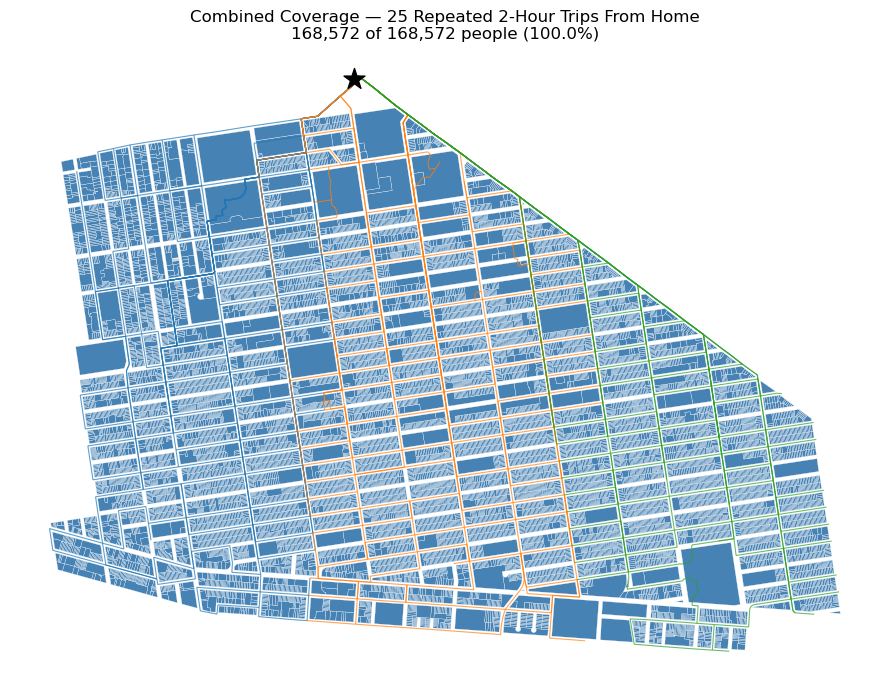

In [21]:
combined_covered = pluto_ft.geometry.intersects(combined_buffer)
fig, ax = plt.subplots(figsize=(9, 9))
pluto_plot[~combined_covered].plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)
pluto_plot[combined_covered].plot(ax=ax, color="steelblue", edgecolor="white", linewidth=0.2)
for zone in ZONE_ORDER:
    for t in results[zone]["trips"]:
        gpd.GeoSeries([t["route_line"]], crs=BUFFER_CRS).to_crs(WORKING_CRS).plot(
            ax=ax, color=ZONE_COLORS[zone], linewidth=0.8, alpha=0.7
        )
house_pt_plot.plot(ax=ax, color="black", marker="*", markersize=250, zorder=6)
ax.set_title(
    f"Combined Coverage — {total_trips_all} Repeated 2-Hour Trips From Home\n"
    f"{combined_pop:,.0f} of {total_pop:,.0f} people ({combined_pop/total_pop*100:.1f}%)",
    fontsize=12
)
ax.axis("off")
plt.tight_layout()
plt.show()

In [22]:
fig.savefig("outputs/multi_trip_ceiling_coverage.png", dpi=150, bbox_inches="tight")

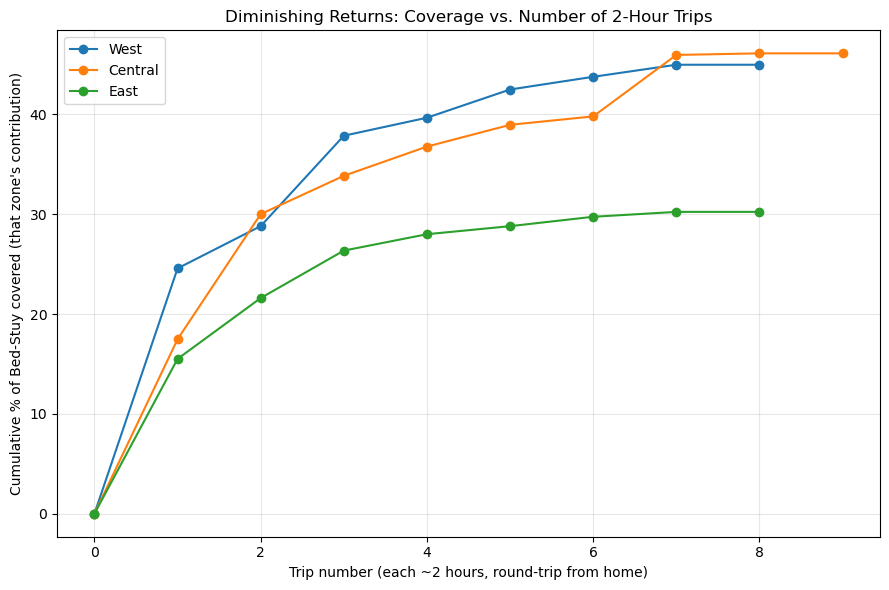

In [23]:
fig, ax = plt.subplots(figsize=(9, 6))
for zone in ZONE_ORDER:
    cum_buf, xs, ys = None, [0], [0]
    for i, t in enumerate(results[zone]["trips"], start=1):
        cum_buf = t["route_buffer"] if cum_buf is None else unary_union([cum_buf, t["route_buffer"]])
        pop = pluto_ft.loc[pluto_ft.geometry.intersects(cum_buf), "est_pop_per_lot"].sum()
        xs.append(i)
        ys.append(pop / total_pop * 100)
    ax.plot(xs, ys, marker="o", color=ZONE_COLORS[zone], label=zone)

ax.set_xlabel("Trip number (each ~2 hours, round-trip from home)")
ax.set_ylabel("Cumulative % of Bed-Stuy covered (that zone's contribution)")
ax.set_title("Diminishing Returns: Coverage vs. Number of 2-Hour Trips")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
fig.savefig("outputs/multi_trip_convergence_curve.png", dpi=150, bbox_inches="tight")